# EA722 – Laboratório de Controle e Servomecanismo

## Experiência 4: Projeto via Lugar das Raízes

Universidade Estadual de Campinas – UNICAMP <br>
Faculdade de Engenharia Elétrica e de Computação – FEEC <br>

**Professores:** Fernando J. Von Zuben / Caíque Santos Lima <br>
**Grupo / Bancada:** T1, T2, R1, R2 ou E <br>
**Turma:** K, L, U ou V <br>
**Aluno(a):** , **RA:** ?????? <br>
**Aluno(a):** , **RA:** ?????? <br>
**Aluno(a):** , **RA:** ?????? <br>

## Bibliotecas

In [ ]:
try:
    import control
except ImportError:
    !pip install control
    import control

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import random
import math
from tqdm import tqdm

# # Google Drive Mount (Colab)
# from google.colab import drive
# drive.mount('/content/drive')

## Funções

In [ ]:
def regiao_permitida_polos(real, imag, T_s):
    # =========================
    # Domínio das retas
    # =========================
    x = np.linspace(-5, 1, 400)

    # Retas que formam o "V"
    y_sup = imag/real * x
    y_inf = -imag/real * x

    # Limite vertical
    x_lim = -4/T_s  # sigma_d = omega_n * zeta = 4 / Ts


    # =========================
    # Criando figura
    # =========================
    fig = go.Figure()

    # Retas
    fig.add_trace(go.Scatter(
        x=x, y=y_sup,
        mode='lines',
        name='Reta superior'
    ))

    fig.add_trace(go.Scatter(
        x=x, y=y_inf,
        mode='lines',
        name='Reta inferior'
    ))

    # Linha vertical (restrição)
    fig.add_trace(go.Scatter(
        x=[x_lim, x_lim],
        y=[-5, 5],
        mode='lines',
        line=dict(dash='dash'),
        name=f'σ_d = {x_lim:.2f}'
    ))

    # =========================
    # Região sombreada
    # =========================
    x_fill = np.linspace(-5, x_lim, 400)

    # IMPORTANTE: usar as mesmas equações das retas
    y_top = imag/real * x_fill
    y_bottom = -imag/real * x_fill

    fig.add_trace(go.Scatter(
        x=np.concatenate([x_fill, x_fill[::-1]]),
        y=np.concatenate([y_top, y_bottom[::-1]]),
        fill='toself',
        fillcolor='rgba(255, 255, 0, 0.5)',
        line=dict(color='rgba(0,0,0,0)'),
        name='Região permitida'
    ))

    # =========================
    # Layout
    # =========================
    fig.update_layout(
        title=dict(text='Região permitida (polos)',
                   x=0.5,),
        xaxis=dict(range=[-5, 2], zeroline=True),
        yaxis=dict(range=[-5, 5], zeroline=True),
        showlegend=True,
        width=600,
        height=500,
    )

    fig.show()

In [ ]:
def plota_resposta(zero, polo, K):
    # ========================
    # Planta
    # ========================
    G = control.TransferFunction(?????)  # Incluir aqui a função de transferência da planta, obtida por você na atividade (a)

    # ========================
    # Sistemas em malha fechada
    # ========================
    # Sem compensador
    T_open = control.feedback(G, 1)

    # Com compensador avanço
    C = control.TransferFunction([1, zero], [1, polo]) * K
    T_comp = control.feedback(C * G, 1)

    # ========================
    # Tempo de simulação
    # ========================
    t = np.arange(0, 10.1, 0.01)

    # Resposta ao degrau
    t1, y1 = control.step_response(T_open, T=t)
    t2, y2 = control.step_response(T_comp, T=t)

    # ========================
    # Métricas de desempenho
    # ========================
    info_open = control.step_info(T_open)
    info_comp = control.step_info(T_comp)

    print("=== Sem compensador ===")
    print(f"Tempo de acomodação: {info_open['SettlingTime']:.4f} s")
    print(f"Sobressinal: {info_open['Overshoot']:.2f} %")

    print("\n=== Com compensador avanço ===")
    print(f"Tempo de acomodação: {info_comp['SettlingTime']:.4f} s")
    print(f"Sobressinal: {info_comp['Overshoot']:.2f} %")

    # ========================
    # Gráfico da resposta
    # ========================
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=t1, y=y1, name="Sem compensador"))
    fig.add_trace(go.Scatter(x=t2, y=y2, name="Com avanço"))

    fig.update_layout(
        title=dict(text='Resposta ao degrau',
                   x=0.5,),
        xaxis_title="Tempo (s)",
        yaxis_title="Saída",
        width=650,
        height=500,
    )

    fig.show()

    # =====================================
    # Gráfico apenas da resposta compensada
    # =====================================
    t = np.arange(0, 3.01, 0.01)

    # Resposta ao degrau
    t3, y3 = control.step_response(T_comp, T=t)
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=t3, y=y3))

    fig.update_layout(
        title=dict(text='Resposta ao degrau do sistema compensado',
                   x=0.5,),
        xaxis_title="Tempo (s)",
        yaxis_title="Saída",
        width=650,
        height=500,
    )

    fig.show()

In [ ]:
def plota_resposta_c(zero, polo, K):
    # ========================
    # Planta
    # ========================
    G = control.TransferFunction([1.5], [0.025, 1, 0]) # Função de transferência do motor DC

    # ========================
    # Sistemas em malha fechada
    # ========================
    # Sem compensador
    T_open = control.feedback(G, 1)

    # Com compensador avanço
    C = control.TransferFunction([1, zero], [1, polo]) * K
    T_comp = control.feedback(C * G, 1)

    # ========================
    # Tempo de simulação
    # ========================
    t = np.arange(0, 4.1, 0.01)

    # Resposta ao degrau
    t1, y1 = control.step_response(T_open, T=t)
    t2, y2 = control.step_response(T_comp, T=t)

    # ========================
    # Métricas de desempenho
    # ========================
    info_open = control.step_info(T_open)
    info_comp = control.step_info(T_comp)

    print("=== Sem compensador ===")
    print(f"Tempo de acomodação: {info_open['SettlingTime']:.4f} s")
    print(f"Sobressinal: {info_open['Overshoot']:.2f} %")

    print("\n=== Com compensador avanço ===")
    print(f"Tempo de acomodação: {info_comp['SettlingTime']:.4f} s")
    print(f"Sobressinal: {info_comp['Overshoot']:.2f} %")

    # ========================
    # Gráfico da resposta
    # ========================
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=t1, y=y1, name="Sem compensador"))
    fig.add_trace(go.Scatter(x=t2, y=y2, name="Com avanço"))

    fig.update_layout(
        title=dict(text='Resposta ao degrau',
                   x=0.5,),
        xaxis_title="Tempo (s)",
        yaxis_title="Saída",
        width=650,
        height=500,
    )

    fig.show()

    # =====================================
    # Gráfico apenas da resposta compensada
    # =====================================
    t = np.arange(0, 0.201, 0.001)

    # Resposta ao degrau
    t3, y3 = control.step_response(T_comp, T=t)
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=t3, y=y3))

    fig.update_layout(
        title=dict(text='Resposta ao degrau do sistema compensado',
                   x=0.5,),
        xaxis_title="Tempo (s)",
        yaxis_title="Saída",
        width=650,
        height=500,
    )

    fig.show()

In [ ]:
def calcula_wn_zeta(sys):
    polos = control.poles(sys)

    # Ordena pelos polos mais dominantes (real mais próximo de zero)
    polos = sorted(polos, key=lambda p: abs(np.real(p)))

    # Pega o primeiro polo complexo (ou dominante)
    for p in polos:
        if np.imag(p) != 0:
            sigma = np.real(p)
            wd = np.imag(p)

            wn = np.sqrt(sigma**2 + wd**2)
            zeta = -sigma / wn
            return wn, zeta

    return None, None

In [ ]:
def plota_resposta_2(zero, polo, K):
    # ========================
    # Planta
    # ========================
    G = control.TransferFunction([10], [1, 1, 0])

    # ========================
    # Sistemas em malha fechada
    # ========================
    T_open = control.feedback(G, 1)

    C = control.TransferFunction([1, -zero], [1, -polo]) * K
    T_comp = control.feedback(C * G, 1)

    # ========================
    # Tempo de simulação
    # ========================
    t = np.linspace(0, 10, 1000)

    t1, y1 = control.step_response(T_open, t)
    t2, y2 = control.step_response(T_comp, t)

    # ========================
    # Métricas de desempenho
    # ========================
    info_open = control.step_info(T_open)
    info_comp = control.step_info(T_comp)

    wn_open, zeta_open = calcula_wn_zeta(T_open)
    wn_comp, zeta_comp = calcula_wn_zeta(T_comp)

    print("=== Sem compensador ===")
    print(f"Tempo de acomodação: {info_open['SettlingTime']:.4f} s")
    print(f"Sobressinal: {info_open['Overshoot']:.2f} %")
    if wn_open:
        print(f"ω_n: {wn_open:.4f}")
        print(f"ζ: {zeta_open:.4f}")

    print("\n=== Com compensador avanço ===")
    print(f"Tempo de acomodação: {info_comp['SettlingTime']:.4f} s")
    print(f"Sobressinal: {info_comp['Overshoot']:.2f} %")
    if wn_comp:
        print(f"ω_n: {wn_comp:.4f}")
        print(f"ζ: {zeta_comp:.4f}")

    # ========================
    # Gráfico
    # ========================
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=t1, y=y1, name="Sem compensador"))
    fig.add_trace(go.Scatter(x=t2, y=y2, name="Com avanço"))

    fig.update_layout(
        title=dict(text='Resposta ao degrau', x=0.5),
        xaxis_title="Tempo (s)",
        yaxis_title="Saída",
        width=650,
        height=500,
    )

    fig.show()

In [ ]:
def regiao_permitida_polos_c(real, imag, T_s):
    # =========================
    # Domínio das retas
    # =========================
    x = np.linspace(-50, 1, 400)

    # Retas que formam o "V"
    y_sup = imag/real * x
    y_inf = -imag/real * x

    # Limite vertical
    x_lim = -4/T_s  # sigma_d = omega_n * zeta = 4 / Ts


    # =========================
    # Criando figura
    # =========================
    fig = go.Figure()

    # Retas
    fig.add_trace(go.Scatter(
        x=x, y=y_sup,
        mode='lines',
        name='Reta superior'
    ))

    fig.add_trace(go.Scatter(
        x=x, y=y_inf,
        mode='lines',
        name='Reta inferior'
    ))

    # Linha vertical (restrição)
    fig.add_trace(go.Scatter(
        x=[x_lim, x_lim],
        y=[-50, 50],
        mode='lines',
        line=dict(dash='dash'),
        name=f'σ_d = {x_lim:.2f}'
    ))

    # =========================
    # Região sombreada
    # =========================
    x_fill = np.linspace(-50, x_lim, 400)

    # IMPORTANTE: usar as mesmas equações das retas
    y_top = imag/real * x_fill
    y_bottom = -imag/real * x_fill

    fig.add_trace(go.Scatter(
        x=np.concatenate([x_fill, x_fill[::-1]]),
        y=np.concatenate([y_top, y_bottom[::-1]]),
        fill='toself',
        fillcolor='rgba(255, 255, 0, 0.5)',
        line=dict(color='rgba(0,0,0,0)'),
        name='Região permitida'
    ))

    # =========================
    # Layout
    # =========================
    fig.update_layout(
        title=dict(text='Região permitida (polos)',
                   x=0.5,),
        xaxis=dict(range=[-50, 2], zeroline=True),
        yaxis=dict(range=[-50, 50], zeroline=True),
        showlegend=True,
        width=600,
        height=500,
    )

    fig.show()

In [ ]:
def plota_resposta_comparativa(zero, polo, K, zero2, polo2, K2):
    # ========================
    # Planta
    # ========================
    G = control.TransferFunction(?????)  # planta
    G2 = control.TransferFunction([1.5], [0.025, 1, 0])  # atuador

    # ========================
    # Sistemas em malha fechada
    # ========================

    # Com compensador avanço e atuador ideal
    C = control.TransferFunction([1, zero], [1, polo]) * K
    T_ideal = control.feedback(C * G, 1)

    # Com compensador avanço e atuador real
    C2 = control.TransferFunction([1, zero2], [1, polo2]) * K2
    Atuador_real = control.feedback(C2 * G2, 1)
    T_real = control.feedback(C * Atuador_real * G, 1)

    # 2. Create a time vector and a sequence of steps
    T = np.arange(0, 30.01, 0.01)
    U = np.where(T < 5.0, 1, np.where(T < 10.0, 0, np.where(T < 15.0, -1, np.where(T < 20.0, 0, np.where(T < 25.0, 1, 0)))))

    # Simulates the time-domain response of a linear system to a specific, user-defined input
    t1, y1 = control.forced_response(T_ideal, T, U)
    t2, y2 = control.forced_response(T_real, T, U)

    # ==============================
    # Gráfico do sinal de referência
    # ==============================
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=t1, y= U))

    fig.update_layout(
        xaxis_title="Tempo (s)",
        yaxis_title="Sinal de referência",
        width=650,
        height=500,
    )

    fig.show()

    # =================================
    # Gráfico das respostas sobrepostas
    # =================================
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=t1, y=y1, name="Atuador ideal"))
    fig.add_trace(go.Scatter(x=t2, y=y2, name="Atuador real"))

    fig.update_layout(
        title=dict(text='Resposta ao degrau',
                   x=0.5,),
        xaxis_title="Tempo (s)",
        yaxis_title="Saída",
        width=650,
        height=500,
    )

    fig.show()

    # =======================================
    # Gráfico da diferença entre as respostas
    # =======================================
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=t1, y= y1 - y2))

    fig.update_layout(
        title=dict(text='Diferença entre as respostas ao degrau',
                   x=0.5,),
        xaxis_title="Tempo (s)",
        yaxis_title="Saída",
        width=650,
        height=500,
    )

    fig.show()

## 1. Projeto de um compensador avanço (*lead compensator*) via lugar das raízes + Controle em cascata

### 1. (a)

> Função de transferência $G(s)=\frac{R(s)}{Θ(s)}$





### 1. (b)

> Projeto do compensador avanço $C(s)$

**Especificações requeridas**

* Sobressinal (*overshoot*, $OS$)

$$
OS \leq 5\%
$$

* Tempo de acomodação ($T_s$):

$$
T_s \leq 3 \ \text{s}
$$





In [ ]:
zeta = 0.0 # @param
omega_n = 0.0 # @param

real = -2*zeta*omega_n / 2

imag = np.sqrt(abs((2*zeta*omega_n)**2-4*1*omega_n**2)) / 2

print(f"s_D = {real} ± j{imag}")

T_s = 3.0 # @param

**Região de alocação dos polos**

Para atender às especificações exigidas, o polo $s_D$ deve ser posicionado dentro da região permitida.

In [ ]:
regiao_permitida_polos(real, imag, T_s)

Com base na região de alocação, escolher convenientemente a posição do polo $s_D$ :

In [ ]:
real = 0.0  # @param
imag = 0.0  # @param

print(f"s_D = {real} ± j{imag}")

**Escolha do compensador avanço**

Forma padrão:

$$
C(s) = K \frac{s+z}{s+p}, z<p
$$

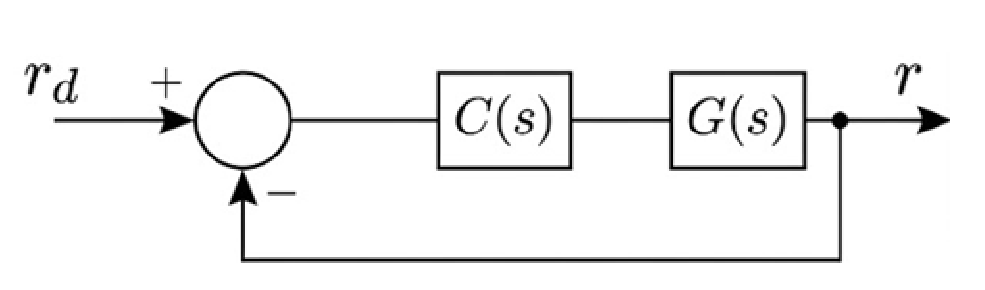

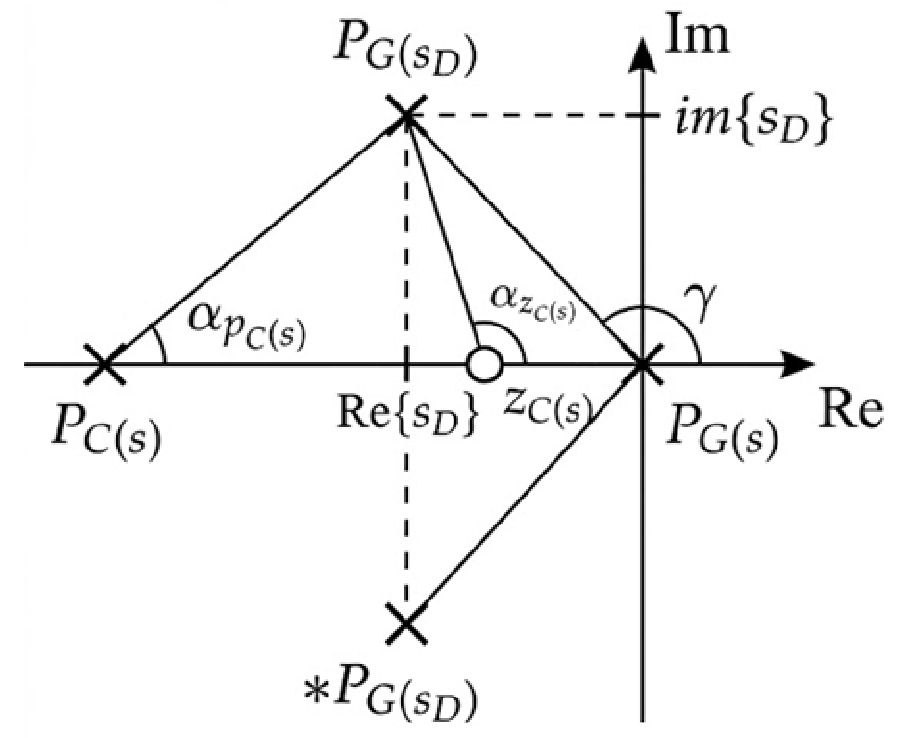

**Estratégia**

* Escolhemos um zero:

$$
z = 0.01
$$

In [ ]:
zero = 0.01 # @param

Isso coloca o zero próximo da origem → comum quando a planta tem polos em zero.

* Agora calculamos o polo do controlador avanço para fornecer a fase necessária.







In [ ]:
# Comando útil
math.degrees(math.atan(abs(imag)/abs(real)))



Encontrando o valor de $K$ do compensador:

$$
K_{C(s)}=\frac{1}{\left|\frac{s+z_{C(s)}}{s+p_{C(s)}}G(s)\right|_{s=s_d} }
$$

In [ ]:
# polo desejado
s = real + 1j*imag

# compensador (sem K)
C = (s + zero) / (s + polo)

G = ??????  # função de transferência da planta

K = 1 / abs(C * G)

print(K)


$$
\boxed{C(s) = ????? \frac{s+?????}{s+?????}}
$$

In [ ]:
plota_resposta(zero, polo, K)

### 1. (c)

> Projeto de um controlador $C_m(s)$ da classe PD usando técnicas baseadas no lugar das raízes

**Especificações requeridas**

* Sobressinal (*overshoot*, $OS$)

$$
OS \leq 20\%
$$

* Tempo de acomodação ($T_s$):

$$
T_s \leq 0.25 \ \text{s}
$$


In [ ]:
zeta = 0.0 # @param
omega_n = 0.0 # @param

real = -2*zeta*omega_n / 2

imag = np.sqrt(abs((2*zeta*omega_n)**2-4*1*omega_n**2)) / 2

print(f"s_D = {real} ± j{imag}")

T_s = 0.25 # @param

**Região de alocação dos polos**

Para atender às especificações exigidas, o polo $s_D$ deve ser posicionado dentro da região permitida.

In [ ]:
regiao_permitida_polos_c(real, imag, T_s)

Portanto, basta escolher a posição do polo $s_D$ dentro da região amarela:

In [ ]:
real = 0.0  # @param
imag = 0.0  # @param

print(f"s_D = {real} ± j{imag}")

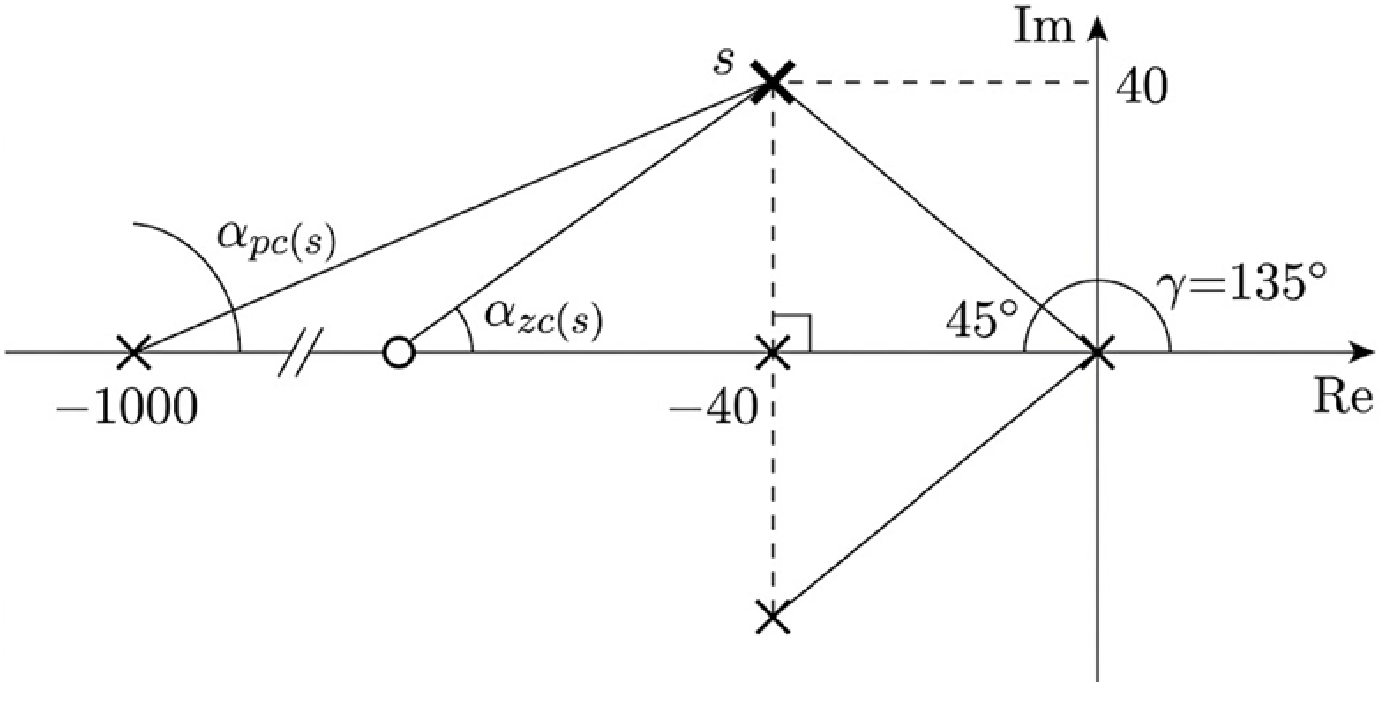

**Método do lugar das raízes**

* Atuador sem compensação:

$$
L(s) = K \frac{1.5}{s(0.025s+1)}
$$

Portanto, $G_m(s)$ possui dois polos:

* $p_1 = 0$

* $p_2 = -40$


**Estratégia**

* Escolhemos um polo:

$$
p = -1000
$$

In [ ]:
polo2 = 1000 # @param

* Agora calculamos o zero do controlador avanço.


Encontrando o valor de $K$ do compensador:

In [ ]:
# polo desejado
s = real + 1j*imag

# compensador (sem K)
C2 = (s + zero2) / (s + polo2)

G2 = 1.5 / (s*(0.025*s+1))  # planta

K2 = 1 / abs(C2 * G2)

print(K2)

$$
\boxed{C(s) = ????? \frac{s+?????}{s+1000}}
$$

In [ ]:
plota_resposta_c(zero2, polo2, K2)

### 1. (d)

In [ ]:
plota_resposta_comparativa(zero, polo, K, zero2, polo2, K2)

## 2. Projeto de um compensador avanço (*lead compensator*) pelo método da abscissa

> Projeto do compensador avanço $C(s)$ pelo método da abscissa

**Especificações requeridas**

* Fator de amortecimento ($ζ$)

$$
ζ = \frac{1}{2}
$$

* Frequência natural ($ω_n$):

$$
ω_n = 2 \ \text{rad/s}
$$


In [ ]:
zeta = 0.5 # @param
omega_n = 2 # @param

real = -2*zeta*omega_n / 2

imag = np.sqrt(abs((2*zeta*omega_n)**2-4*1*omega_n**2)) / 2

print(f"s_D = {real} ± j{imag}")

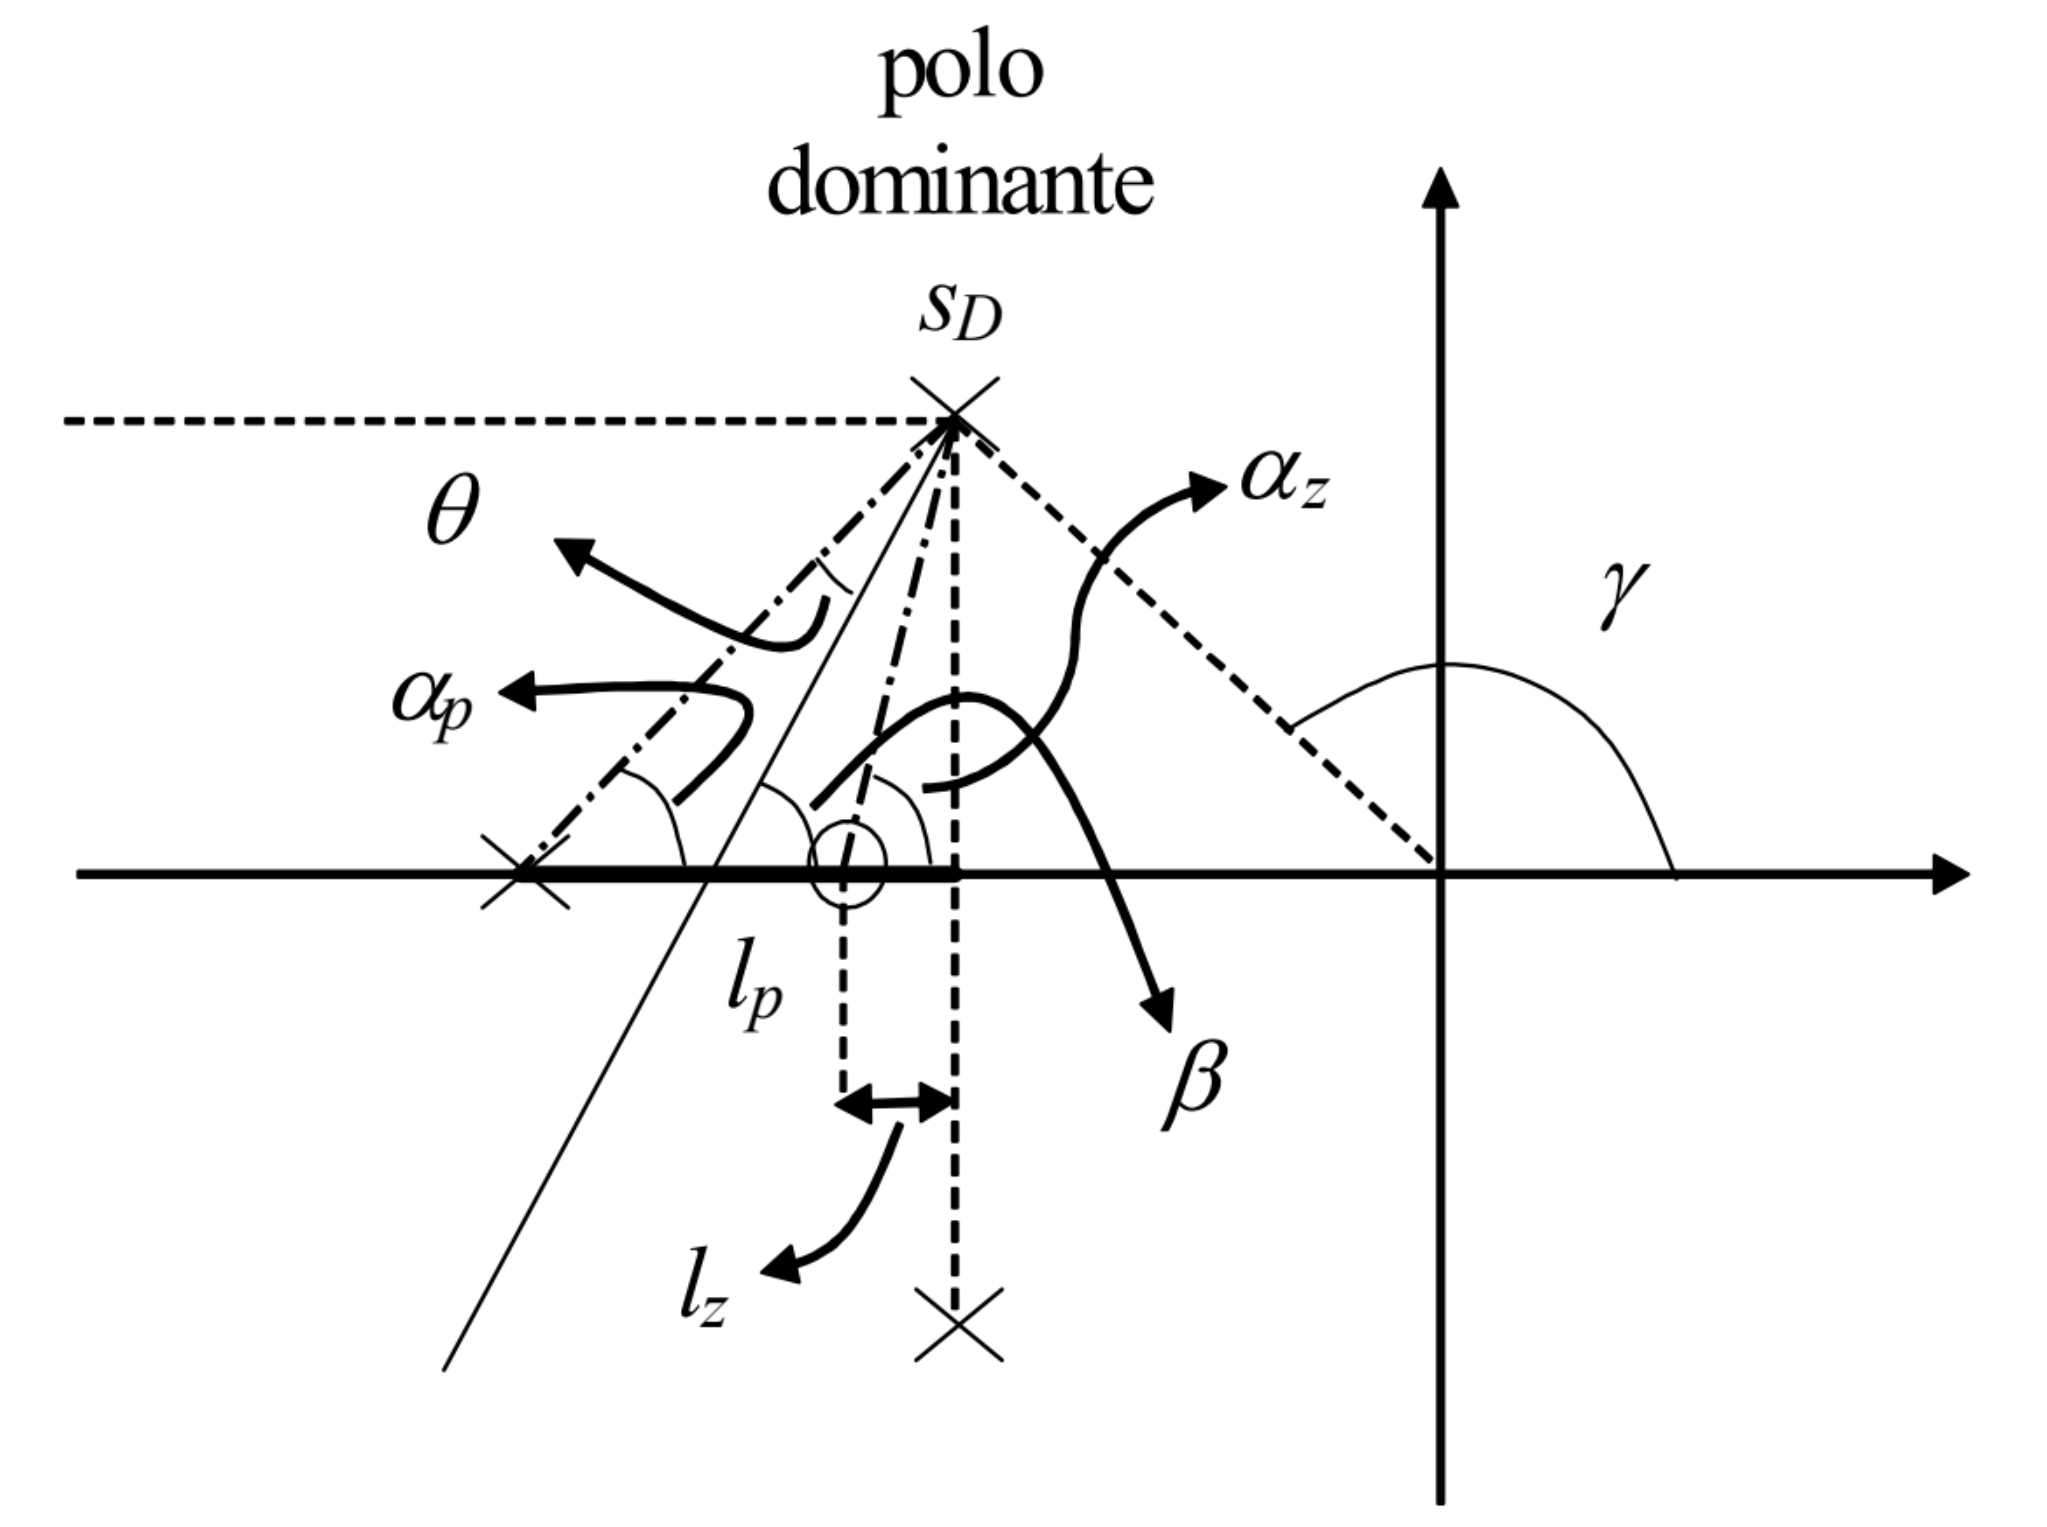

**Ângulo γ**:

$$
\gamma = 180° + \tan^{-1}\left(\frac{\text{Im}(s_D)}{\text{Re}(s_D)}\right)
$$

In [ ]:
gamma = 180 + math.degrees(math.atan(imag/real))
print(f"gamma = {gamma}")

**Ângulo β:**

$$
\beta = \frac{\gamma}{2}
$$

In [ ]:
beta = gamma / 2
print(f"beta = {beta}")

**Ângulo da planta $\angle G(s_D)$:**

Polos da planta:

* $p1=0$

* $p2=-1$

Contribuição do ângulo do polo em 0:

$$
\angle(s_D0) = ?????^\circ
$$

Contribuição do ângulo do polo em -1:

$$
\angle(s_D1) = ?????^\circ
$$

Soma:

$$
\angle G(s_D) = ?????^\circ
$$


**Cálculo de $θ$:**

$$
\theta = \frac{-180^\circ - \angle G(s_D)}{2}
$$

In [ ]:
theta = ?????
print(f"theta = {theta}")

**Ângulos do compensador**

$$
\alpha_p = \beta - \theta
$$

$$
\alpha_z = \beta + \theta
$$


In [ ]:
alpha_p = beta-theta
print(f"alpha_p = {alpha_p}")

In [ ]:
alpha_z = beta+theta
print(f"alpha_z = {alpha_z}")

**Distância $l_p$ e $l_z$**

Para o polo:

$$
l_p = \frac{\text{Im}(s_D)}{\tan(\alpha_p)}
$$


In [ ]:
l_p = imag / math.tan(math.radians(alpha_p))
print(f"l_p = {l_p}")

Para o zero:

$$
l_z = \frac{\text{Im}(s_D)}{\tan(\alpha_z)}
$$

In [ ]:
l_z = imag / math.tan(math.radians(alpha_z))
print(f"l_z = {l_z}")

**Localização do polo e zero**

Polo do compensador:

$$
Re\{polo\} = Re\{s_D\} - l_p
$$

Zero do compensador:

$$
Re\{zero\} = Re\{s_D\} - l_z
$$

In [ ]:
polo = real - l_p
print(f"polo = {polo}")

zero = real - l_z
print(f"zero = {zero}")

Encontrando o valor de $K$ do compensador:

In [ ]:
# polo desejado
s = real + 1j*imag

# compensador (sem K)
C = (s + zero) / (s + polo)

G = 10 / (s*(s+1))  # planta

K = 1 / abs(C * G)

print(K)

$$
\boxed{C(s) = ????? \frac{s+?????}{s+?????}}
$$

In [ ]:
plota_resposta_2(zero, polo, K)